# Brain Tumor Segmentation with U-Net

This notebook implements a **U-Net** convolutional neural network from scratch using PyTorch and applies it to **brain tumor segmentation** on MRI scans from the [BraTS 2020 dataset](https://www.med.upenn.edu/cbica/brats2020/).

**What the model does:** given a 2-D axial slice of a FLAIR MRI brain scan, it predicts a pixel-wise binary mask that highlights the tumor region.

---

## Table of Contents
1. [Setup & Dependencies](#1-setup--dependencies)
2. [Mount Google Drive & Extract Data](#2-mount-google-drive--extract-data)
3. [U-Net Architecture](#3-u-net-architecture)
   - 3.1 Double Convolution Block
   - 3.2 Encoder Block
   - 3.3 Decoder Block
   - 3.4 Full U-Net
4. [Dataset & DataLoaders](#4-dataset--dataloaders)
5. [Loss Function — Dice Loss](#5-loss-function--dice-loss)
6. [Training](#6-training)
7. [Training Curve](#7-training-curve)
8. [Evaluation — Dice Score](#8-evaluation--dice-score)
9. [Qualitative Results](#9-qualitative-results)
10. [Conclusion](#10-conclusion)


## 1. Setup & Dependencies

We use three libraries beyond the standard PyTorch/torchvision stack:
- **`nibabel`** — reads NIfTI (`.nii`) medical imaging files
- **`numpy`** — array manipulation and preprocessing
- **`matplotlib`** — visualization


In [ ]:
!pip install nibabel numpy matplotlib

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

## 2. Mount Google Drive & Extract Data

The BraTS 2020 training dataset is stored as a ZIP archive on Google Drive (`brain.zip`). We mount the drive and extract it once to a local path.


> **Folder structure after extraction:**
> ```
> brain_data/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/
>   BraTS20_Training_001/
>     BraTS20_Training_001_flair.nii
>     BraTS20_Training_001_seg.nii
>     ...
> ```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path    = '/content/drive/MyDrive/brain.zip'
extract_dir = '/content/brain_data'


if not os.path.exists(extract_dir):
   with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
else:
    print("Already extracted, skipping.")

## 3. U-Net Architecture

U-Net is the standard architecture for biomedical image segmentation. Its key idea is the **symmetric encoder–decoder** with **skip connections** that route fine spatial detail from the contracting path directly to the expansive path — preventing the network from losing precise boundary information at the bottleneck.

### 3.1 Double Convolution Block

Every stage (encoder, decoder, bottleneck) applies two consecutive `Conv2d → BatchNorm → ReLU` operations. Batch normalisation stabilises training; the double convolution lets the network learn richer features without adding more downsampling steps.


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):

        return self.block(x)

### 3.2 Encoder Block

Each encoder block applies `DoubleConv` and then `MaxPool2d(2×2)`. It returns **two** tensors:
- `features` — the full-resolution feature map saved as a skip connection
- `downsampled` — the max-pooled output passed to the next stage


In [ ]:
class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):

        features = self.conv(x)
        downsampled = self.pool(features)

        return features, downsampled


### 3.3 Decoder Block

`ConvTranspose2d` doubles the spatial resolution. The upsampled tensor is then concatenated along the channel axis with the skip connection from the matching encoder level. A `DoubleConv` then fuses the combined channels, blending semantic meaning and spatial detail into a single representation.



In [ ]:
class DecoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x, skip):

        x = self.upsample(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)

        return x

### 3.4 Full U-Net

The complete network stacks four encoder blocks, a bottleneck with 30 % spatial dropout (to regularise the deepest representation), four symmetric decoder blocks, and a final 1×1 convolution that collapses the 64-channel feature map to a single-channel logit map — one logit per pixel.

| Stage | Channels | Spatial size |
|-------|----------|--------------|
| Input | 1 | 256 × 256 |
| Enc 1 | 64 | 256 → 128 |
| Enc 2 | 128 | 128 → 64 |
| Enc 3 | 256 | 64 → 32 |
| Enc 4 | 512 | 32 → 16 |
| Bottleneck | 1024 | 16 × 16 |
| Dec 4 | 512 | 16 → 32 |
| Dec 3 | 256 | 32 → 64 |
| Dec 2 | 128 | 64 → 128 |
| Dec 1 | 64 | 128 → 256 |
| Output | 1 | 256 × 256 |


In [ ]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ── Encoder (going down the left side of the U) ──────────
        self.enc1 = EncoderBlock(1,   64)
        # input:  1 channel (grayscale), output: 64 feature maps
        # image stays 256x256 inside, then halves to 128x128

        self.enc2 = EncoderBlock(64,  128)
        # input: 64 channels, output: 128 feature maps
        # image: 128x128 → 64x64

        self.enc3 = EncoderBlock(128, 256)
        # input: 128 channels, output: 256 feature maps
        # image: 64x64 → 32x32

        self.enc4 = EncoderBlock(256, 512)
        # input: 256 channels, output: 512 feature maps
        # image: 32x32 → 16x16

        # ── Bottleneck (bottom of the U) ──────────────────────────
        self.bottleneck = nn.Sequential( DoubleConv(512, 1024), nn.Dropout2d(p=0.3))
        # this is the deepest point — smallest image, most features
        # image: 16x16, channels: 1024

        # ── Decoder (going up the right side of the U) ───────────
        self.dec4 = DecoderBlock(1024, 512)
        # image: 16x16 → 32x32

        self.dec3 = DecoderBlock(512,  256)
        # image: 32x32 → 64x64

        self.dec2 = DecoderBlock(256,  128)
        # image: 64x64 → 128x128

        self.dec1 = DecoderBlock(128,  64)
        # image: 128x128 → 256x256

        # ── Final layer ───────────────────────────────────────────
        self.final = nn.Conv2d(64, 1, kernel_size=1)
        # kernel_size=1 means look at one pixel at a time
        # collapses 64 channels down to 1: our tumor probability map
        # output: (batch, 1, 256, 256) — one number per pixel

    def forward(self, x):
        # x starts as shape: (batch, 1, 256, 256)

        # ── Encoder ───────────────────────────────────────────────
        s1, x = self.enc1(x)
        # s1 = skip connection saved at 256x256
        # x  = downsampled to 128x128

        s2, x = self.enc2(x)
        # s2 = skip connection saved at 128x128
        # x  = downsampled to 64x64

        s3, x = self.enc3(x)
        # s3 = skip connection saved at 64x64
        # x  = downsampled to 32x32

        s4, x = self.enc4(x)
        # s4 = skip connection saved at 32x32
        # x  = downsampled to 16x16

        # ── Bottleneck ────────────────────────────────────────────
        x = self.bottleneck(x)
        # x is now 16x16 with 1024 channels
        # the network now "understands" the full context of the image

        # ── Decoder ───────────────────────────────────────────────
        x = self.dec4(x, s4)
        # upsample to 32x32, combine with skip s4

        x = self.dec3(x, s3)
        # upsample to 64x64, combine with skip s3

        x = self.dec2(x, s2)
        # upsample to 128x128, combine with skip s2

        x = self.dec1(x, s1)
        # upsample to 256x256, combine with skip s1
        # now back to full resolution

        x = self.final(x)
        # collapse to 1 channel: tumor probability per pixel
        # output shape: (batch, 1, 256, 256)

        return x

## 4. Dataset & DataLoaders

### Slice selection strategy
Each 3-D MRI volume contains 155 axial slices, but the vast majority are tumour-free. To keep the dataset **informative**, we rank every slice by the number of tumour voxels and keep only the **top-3 most tumour-rich slices** per patient. This gives 1 107 slice pairs across 369 patients.

### Preprocessing (per slice)
1. **Normalisation** — scale intensities to `[0, 1]` using min-max: `(x − min) / (max − min + ε)`
2. **Binary mask** — collapse multi-class BraTS labels (1/2/4) to a single `{0, 1}` whole-tumour mask
3. **Resize** — both image and mask resized to `256 × 256` with `transforms.Resize`

### Train / Val / Test split
| Split | Fraction | Samples |
|-------|----------|---------|
| Train | 80 % | 885 |
| Val   | 10 % | 111 |
| Test  | 10 % | 111 |


In [ ]:
import numpy as np
import nibabel as nib
import torch
from torchvision import transforms
from torch.utils.data import Dataset
import glob

data_root = '/content/brain_data/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

image_paths = sorted(glob.glob(f"{data_root}/**/*_flair.nii"))
mask_paths  = sorted(glob.glob(f"{data_root}/**/*_seg.nii"))

slice_pairs = []
for img_path, mask_path in zip(image_paths, mask_paths):
    mask = nib.load(mask_path).get_fdata()
    num_slices = mask.shape[2]

    tumor_counts = []
    for i in range(num_slices):
        count = (mask[:, :, i] > 0).sum()
        tumor_counts.append(count)

    tumor_counts = np.array(tumor_counts)
    sorted_indices = np.argsort(tumor_counts)[::-1]
    top3 = sorted_indices[:3].tolist()

    for slice_idx in top3:
        slice_pairs.append((img_path, mask_path, slice_idx))

class BrainTumorDataset(Dataset):

      def __init__(self, slice_pairs):
          self.slice_pairs = slice_pairs
          self.resize      = transforms.Resize((256, 256))

      def __len__(self):
          return len(self.slice_pairs)

      def __getitem__(self, index):
          img_path, mask_path, slice_idx = self.slice_pairs[index]
          scan      = nib.load(img_path).get_fdata()
          mask_scan = nib.load(mask_path).get_fdata()

          image = scan[:, :, slice_idx]
          mask  = mask_scan[:, :, slice_idx]

          image = (image - image.min()) / (image.max() - image.min() + 1e-8)
          mask  = (mask > 0).astype(np.float32)

          image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
          image = self.resize(image)
          mask  = torch.tensor(mask,  dtype=torch.float32).unsqueeze(0)
          mask  = self.resize(mask)

          return image, mask

In [ ]:
# split into train, validation and test sets

total = len(slice_pairs)
print(f"total patients: {total}")

# calculate split boundaries
train_end = int(0.80 * total)
val_end   = int(0.90 * total)

train_pairs = slice_pairs[:train_end]

val_pairs   = slice_pairs[train_end:val_end]

test_pairs  = slice_pairs[val_end:]


total patients: 1107


In [ ]:
# create dataset objects
train_dataset = BrainTumorDataset(train_pairs)
val_dataset   = BrainTumorDataset(val_pairs)
test_dataset  = BrainTumorDataset(test_pairs)

In [ ]:
# create dataloaders

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size= 4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size= 4)
test_loader   = DataLoader(test_dataset,  batch_size=4)

## 5. Loss Function — Dice Loss

Cross-entropy is a poor choice for medical segmentation because tumour pixels can be as few as 1–2 % of all pixels.   
 **Dice loss** measures how much the prediction and the ground-truth mask overlap. Imagine two circles — the more they overlap, the lower the loss. A perfect prediction gives a Dice score of 1, so the loss becomes 0. No overlap at all gives a Dice score of 0, so the loss becomes 1.

In [ ]:
def dice_loss(prediction, target):

    # smooth is a small number that is added to prevent division by zero
    smooth = 1e-6

    # sigmoid converts the outputs to probabilities into range (0, 1)
    prediction = torch.sigmoid(prediction)

    # flatten both tensors into 1D lists of numbers
    pred_flat   = prediction.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    dice_score = (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

    return 1.0 - dice_score


## 6. Training

| Hyperparameter | Value |
|----------------|-------|
| Optimiser | Adam |
| Initial LR | 1 × 10⁻⁴ |
| LR scheduler | ReduceLROnPlateau (patience=5, factor=0.5) |
| Max epochs | 50 |
| Batch size | 4 |
| Early stopping patience | 10 epochs |
| Best model criterion | Minimum validation Dice loss |

The best weights are saved to `best_model.pth` whenever the validation loss improves, and reloaded after training for evaluation.


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

num_epochs       = 50
best_val_loss    = float('inf')
patience         = 10       #patience for early stopping
patience_counter = 0
train_losses     = []
val_losses       = []

for epoch in range(num_epochs):

    # ── Training ──────────────────────────────────────────
    model.train()
    total_train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = dice_loss(predictions, masks)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # ── Validation ────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)
            predictions = model(images)
            loss = dice_loss(predictions, masks)
            total_val_loss += loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ── Scheduler ─────────────────────────────────────────
    scheduler.step(avg_val)

    # ── Best Model + Early Stopping ───────────────────────
    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f" Best model saved (val loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# ── Load best model before evaluation ─────────────────────
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded for evaluation.")

Epoch  1/50 | Train: 0.7277 | Val: 0.6850 | LR: 0.000100
 Best model saved (val loss: 0.6850)
Epoch  2/50 | Train: 0.6106 | Val: 0.5869 | LR: 0.000100
 Best model saved (val loss: 0.5869)
Epoch  3/50 | Train: 0.4721 | Val: 0.4428 | LR: 0.000100
 Best model saved (val loss: 0.4428)
Epoch  4/50 | Train: 0.3541 | Val: 0.4645 | LR: 0.000100
  No improvement (1/10)
Epoch  5/50 | Train: 0.2697 | Val: 0.2991 | LR: 0.000100
 Best model saved (val loss: 0.2991)
Epoch  6/50 | Train: 0.2073 | Val: 0.2105 | LR: 0.000100
 Best model saved (val loss: 0.2105)
Epoch  7/50 | Train: 0.1694 | Val: 0.2275 | LR: 0.000100
  No improvement (1/10)
Epoch  8/50 | Train: 0.1500 | Val: 0.2420 | LR: 0.000100
  No improvement (2/10)
Epoch  9/50 | Train: 0.1384 | Val: 0.1725 | LR: 0.000100
 Best model saved (val loss: 0.1725)
Epoch 10/50 | Train: 0.1198 | Val: 0.1905 | LR: 0.000100
  No improvement (1/10)
Epoch 11/50 | Train: 0.1078 | Val: 0.1604 | LR: 0.000100
 Best model saved (val loss: 0.1604)
Epoch 12/50 | Trai

## 7. Training Curve

The plot below shows Dice loss over epochs for both the training and validation sets. Convergence was reached around epoch 34 when early stopping triggered (patience = 10, best val loss at epoch 24).


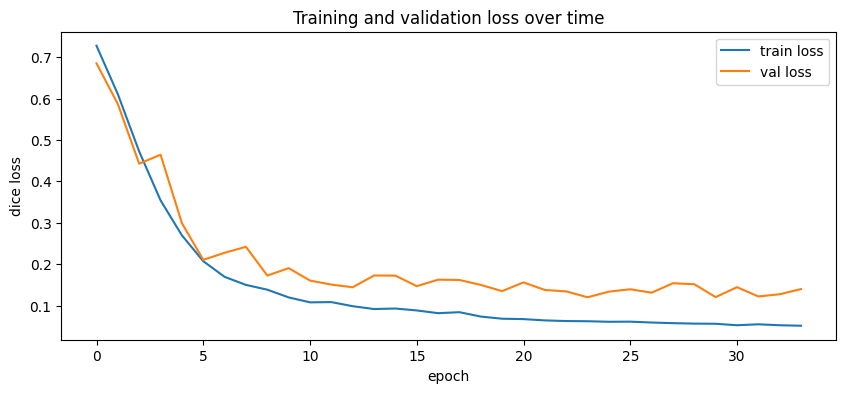

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses,   label='val loss')
plt.xlabel('epoch')
plt.ylabel('dice loss')
plt.title('Training and validation loss over time')
plt.legend()
plt.show()

## 8. Evaluation — Dice Score

We evaluate the **best saved model** on the held-out test set. For each sample we apply a **0.5 threshold** to the sigmoid output to obtain a binary prediction, then compute the Dice score. The mean Dice score is reported over all 111 test samples.


In [ ]:
def evaluate(model, dataset):

    dice_scores = []
    model.to('cpu')
    model.eval()

    with torch.no_grad():
        for index in range(len(dataset)):

            image, mask = dataset[index]

            pred = model(image.unsqueeze(0))
            pred = (torch.sigmoid(pred) > 0.5).float().squeeze().numpy()
            mask = mask.squeeze().numpy()

            intersection = (pred * mask).sum()
            dice = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)
            dice_scores.append(dice)


    print(f"evaluated on {len(dataset)} samples")
    print(f"Dice Score: {np.mean(dice_scores):.4f}")

    return dice_scores

dice_scores = evaluate(model, test_dataset)

evaluated on 111 samples
Dice Score: 0.9025


## 9. Qualitative Results

We visualise a randomly selected test sample, showing:
- **Left** — the raw FLAIR MRI brain scan (grayscale)
- **Centre** — the ground-truth expert annotation (red overlay)
- **Right** — the U-Net prediction (blue overlay)

A high Dice score should be visible as near-perfect overlap between the centre and right panels.


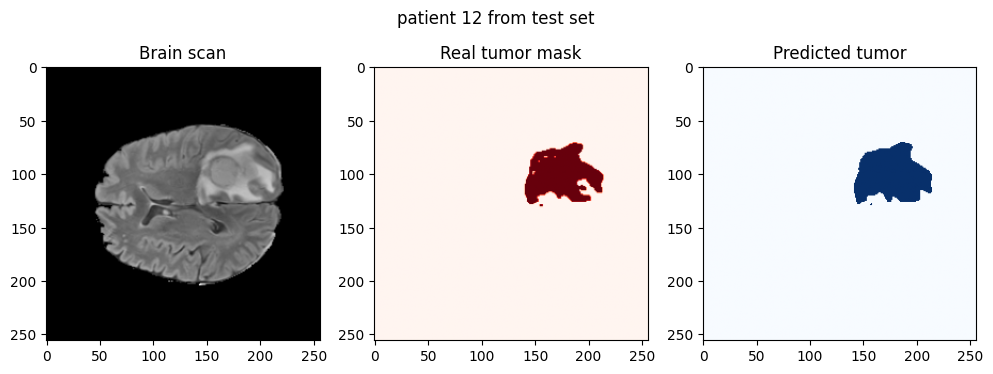

In [ ]:
# Visualization

import random
model.eval()
with torch.no_grad():
    model.to('cpu')
    row       = random.randint(0, len(test_dataset) - 1)
    img, mask = test_dataset[row]

    pred  = model(img.unsqueeze(0))
    pred  = (torch.sigmoid(pred) > 0.5).float().squeeze().numpy()
    img   = img.squeeze().numpy()
    mask  = mask.squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img,  cmap='gray')
axes[0].set_title('Brain scan')

axes[1].imshow(mask, cmap='Reds')
axes[1].set_title('Real tumor mask')

axes[2].imshow(pred, cmap='Blues')
axes[2].set_title('Predicted tumor')

plt.suptitle(f'patient {row} from test set')
plt.show()

## 10. Conclusion

### Results summary

| Metric | Value |
|--------|-------|
| Test Dice Score | **0.9025** |
| Training stopped | Epoch 34 / 50 (early stopping) |
| Best val Dice loss | 0.1201 (epoch 24) |

A Dice score of **~0.90** is confirming that the U-Net architecture generalises well even when trained on a small subset of slices.

### Key design choices
- **Top-3 tumour-rich slices per patient** avoids class imbalance and keeps training tractable on a Colab T4 GPU.
- **Dice loss**  stays reliable even when tumour pixels are vastly outnumbered by background pixels.
- **Skip connections** preserve fine boundary detail across the encoder–decoder gap.
- **Bottleneck dropout (p=0.3)** regularises the deepest representation and reduces overfitting.
- **ReduceLROnPlateau + early stopping** provide adaptive optimisation without manual scheduling.

### Possible improvements
- Use all four BraTS modalities (T1, T1ce, T2, FLAIR) as input channels
- Add data augmentation (random flips, rotations, elastic deformations)
- Train on 3-D volumes with a 3-D U-Net
- Replace Dice loss with a combined Dice + Binary Cross-Entropy loss
- Experiment with deeper encoders (e.g. ResNet or EfficientNet backbone)


